# Results when splitting the real cygnus-a dataset, described in: *A Wideband Polarization Study of Cygnus A with the Jansky Very Large Array. I. The Observations and Data - Sebokolodi et al*

In [1]:
import matplotlib.pyplot as plt
import matplotlib
import numpy
from scipy import signal
import pandas as pd

from rascil.processing_components import create_visibility_from_ms

from radioimaging.util import util
from radioimaging.visibility import residual, weights
from radioimaging.images import images

plt.set_loglevel("critical")
cmap='turbo'
matplotlib.rcParams['figure.figsize'] = [10, 5]

wavelet_type_dict = {"daubechies" : 0, "iuwt" : 1}

wavelet_type = "daubechies"
wavelet_type_idx = wavelet_type_dict[wavelet_type]

runtests = False
niter = 100

/usr/lib/python3.10/abc.py:106: FutureWarning: xarray subclass Visibility should explicitly define __slots__
  cls = super().__new__(mcls, name, bases, namespace, **kwargs)


## PSF and Dirty of split measurement sets cut at $\delta = 5, \ell = 20$
Just loading precomputed images as loading all visibilities here uses too much memory

In [2]:
low_dirty = util.fromfits("../data5/cygnusa_smallbaselines_dirty.fits")
low_psf = util.fromfits("../data5/cygnusa_smallbaselines_psf.fits")
high_dirty = util.fromfits("../data5/cygnusa_longbaselines_dirty.fits")
high_psf = util.fromfits("../data5/cygnusa_longbaselines_psf.fits")

util.plotNImages([low_dirty, low_psf], ["Small baselines dirty", "Small baselines psf"], cmap)
util.plotNImages([high_dirty, high_psf], ["Long baselines dirty", "Long baselines psf"], cmap)

FileNotFoundError: [Errno 2] No such file or directory: '../data5/cygnusa_smallbaselines_dirty.fits'

## Simulation results, plotting L2-norm of residual, as well as the error to a finely sampled dirty map, across the major iterations. Algorithm parameters (obtained via trial and error) are as follows:
#### Small baselines reconstruction: $\lambda = 0.1 \times \|\tilde{\imath}_n\| \times 4^n$
#### Long baselines reconstruction: $\lambda = 0.02 \times \|\tilde{\imath}_n\| \times 2^n$
#### Full reconstruction: $\lambda = 0.01 \times \|\tilde{\imath}_n\| \times 2^n$

In [3]:
nmajor_cyc = 6
path = "../results/cygnus_a/"

data_low = []
data_high = []
data_full = []

residuals_low = []
residuals_high = []
residuals_full = []

curr_deconv_low = None
curr_deconv_high = None

for maj_iter in range(0, nmajor_cyc):
    high_filename = path + "high/dirty_iteration_" + str(maj_iter) + "_channel_0.fits"
    low_filename = path + "low/dirty_iteration_" + str(maj_iter) + "_channel_0.fits"
    full_filename = path + "full/dirty_iteration_" + str(maj_iter) + "_channel_0.fits"
    
    dirty_low = util.fromfits(low_filename)
    dirty_high = util.fromfits(high_filename)
    dirty_full = util.fromfits(full_filename)

    data_low.append(numpy.linalg.norm(dirty_low))
    data_high.append(numpy.linalg.norm(dirty_high))
    data_full.append(numpy.linalg.norm(dirty_full))
    
    residuals_low.append(dirty_low)
    residuals_high.append(dirty_high)
    residuals_full.append(dirty_full)
    

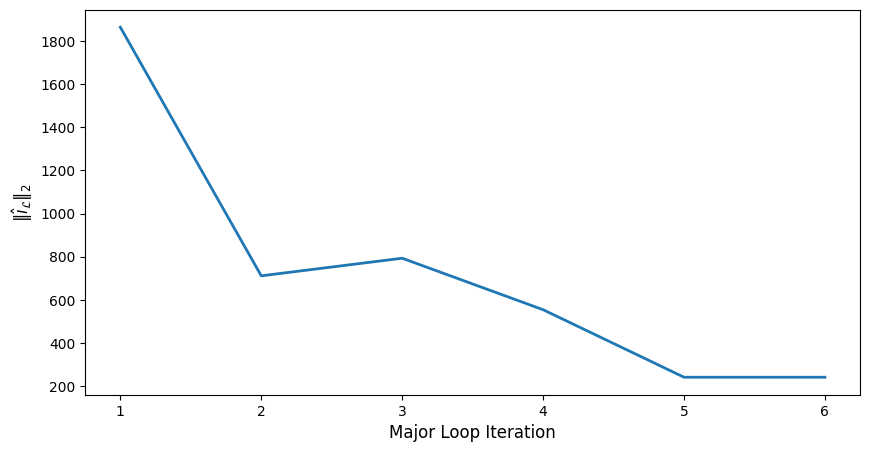

In [4]:
plt.plot(range(1, nmajor_cyc + 1), data_low, lw=2)

plt.xlabel("Major Loop Iteration", fontsize=12)
plt.ylabel("$\|\hat{\imath}_\mathcal{L}\|_2$", fontsize=12)
plt.savefig("../figures/low_dirtyl2_cyga.png", bbox_inches='tight')

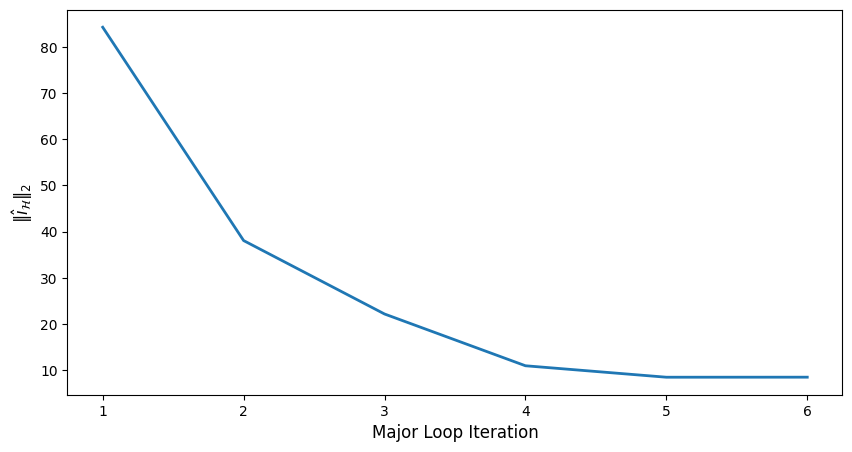

In [5]:
plt.plot(range(1, nmajor_cyc + 1), data_high, lw=2)

plt.xlabel("Major Loop Iteration", fontsize=12)
plt.ylabel("$\|\hat{\imath}_\mathcal{H}\|_2$", fontsize=12)
plt.savefig("../figures/high_dirtyl2_cyga.png", bbox_inches='tight')

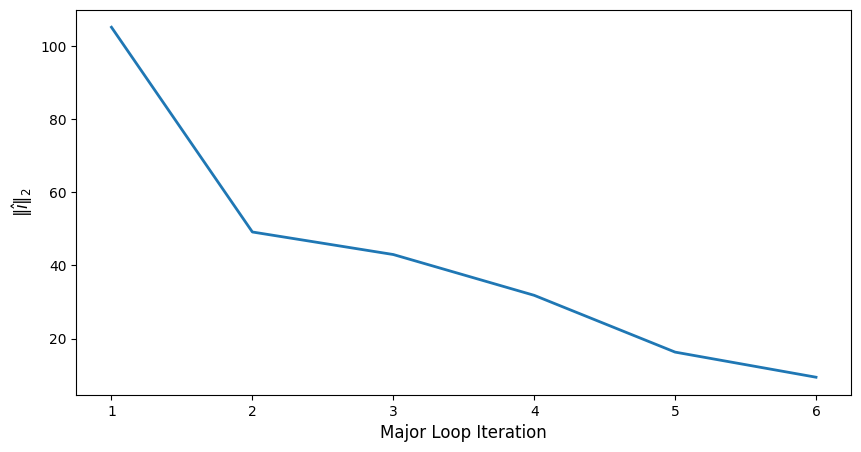

In [6]:
plt.plot(range(1, nmajor_cyc + 1), data_full, lw=2)

plt.xlabel("Major Loop Iteration", fontsize=12)
plt.ylabel("$\|\hat{\imath}\|_2$", fontsize=12)
plt.savefig("../figures/full_dirtyl2_cyga.png", bbox_inches='tight')